### Loading required libraries for textblob and vaderSentiment

In [189]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [191]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


### Loading packages required for this week

In [193]:
import numpy as np
#import tensorflow as tf
#from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import string
import re
import matplotlib.pyplot as plt
import math
from matplotlib import rc
from matplotlib.ticker import FixedLocator

from sklearn.model_selection import train_test_split
from collections import Counter, defaultdict
from bs4 import BeautifulSoup
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()


%matplotlib inline

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/vijsharm/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vijsharm/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

<div style="text-align: center;font-size: 30px;""> Part 1: Using the TextBlob Sentiment Analyzer</div>                       

### Loading required source file "labeledTrainData" for analysis

In [198]:
dftrain = pd.read_csv("labeledTrainData.tsv", header=0, \
                    delimiter="\t", quoting=3)
dftrain.shape

(25000, 3)

In [200]:
dftrain.head()

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."
3,"""3630_4""",0,"""It must be assumed that those who praised thi..."
4,"""9495_8""",1,"""Superbly trashy and wondrously unpretentious ..."


### How many of each positive and negative reviews are there?

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_1364/961267401.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  f.set_xticklabels(['Negative', 'Positive'])


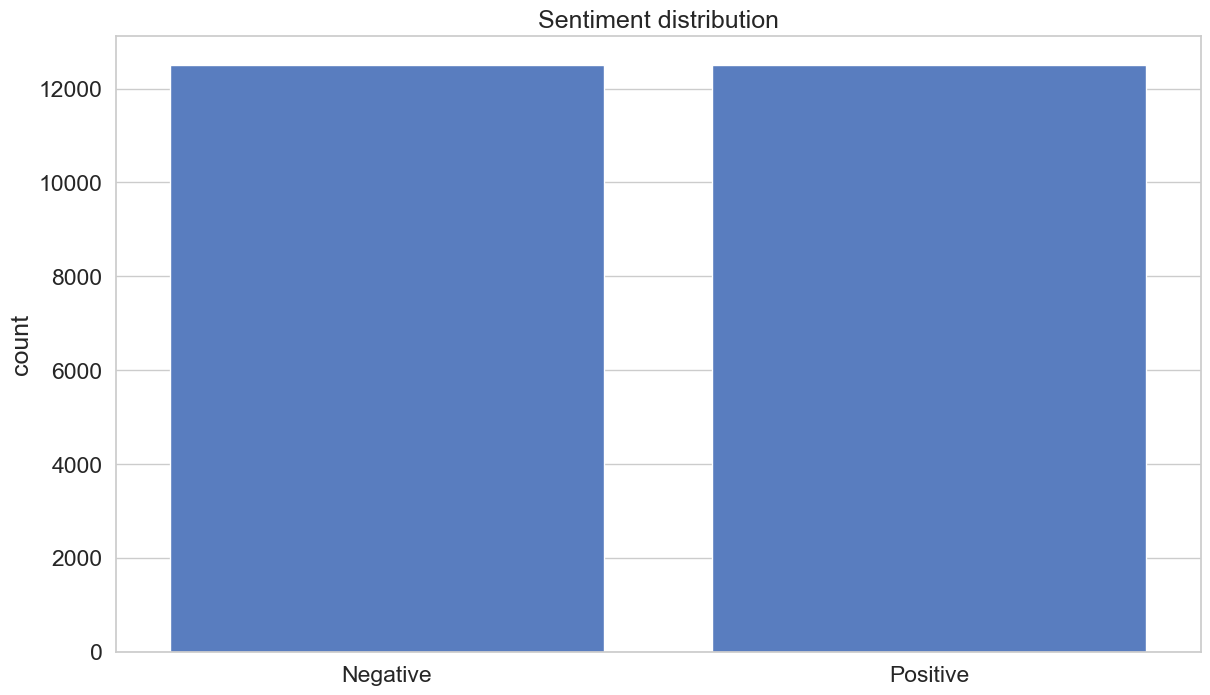

In [203]:
f = sns.countplot(x='sentiment', data=dftrain)
f.set_title("Sentiment distribution")
f.set_xticklabels(['Negative', 'Positive'])
plt.xlabel("");

### Use TextBlob to classify each movie review as positive or negative. Assume that a polarity score greater than or equal to zero is a positive sentiment and less than 0 is a negative sentiment.

In [206]:
from textblob import TextBlob
import pandas as pd

def classify_sentiment(review):
    """
    Classifies a movie review as positive or negative based on its TextBlob polarity score.

    Args:
        review (str): The movie review text.

    Returns:
        str: "Positive" if the polarity score is greater than or equal to 0, "Negative" otherwise.
    """
    analysis = TextBlob(review)
    if analysis.sentiment.polarity >= 0:
        return "Positive"
    else:
        return "Negative"


# Apply the sentiment classification function to each review
dftrain["predicted_sentiment"] = dftrain["review"].apply(classify_sentiment)

# Evaluate the model (replace with your desired evaluation method)
# For example, comparing predicted_sentiment with the actual 'sentiment' column
accuracy = (dftrain["predicted_sentiment"] == dftrain["sentiment"]).mean()

print(f"Accuracy: {accuracy}")

# You can also print a few examples:
print("\nExample classifications:")
print(dftrain[["review", "predicted_sentiment"]].head())

Accuracy: 0.0

Example classifications:
                                              review predicted_sentiment
0  "With all this stuff going down at the moment ...            Positive
1  "\"The Classic War of the Worlds\" by Timothy ...            Positive
2  "The film starts with a manager (Nicholas Bell...            Negative
3  "It must be assumed that those who praised thi...            Positive
4  "Superbly trashy and wondrously unpretentious ...            Negative


### For up to five points extra credit, use another prebuilt text sentiment analyzer, e.g., VADER, and repeat steps (3) and (4).

In [208]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [211]:
def analyze_sentiment_vader(sentence):
    analyzer = SentimentIntensityAnalyzer()
    scores = analyzer.polarity_scores(sentence)
    compound_score = scores['compound']
    if compound_score >= 0.05:
        return 'positive'
    elif compound_score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

In [213]:
dftrain['vader_sentiment'] = dftrain['review'].apply(analyze_sentiment_vader)
vader_accuracy = (dftrain['sentiment'] == dftrain['vader_sentiment']).mean()
print(f'VADER Accuracy: {vader_accuracy}')

VADER Accuracy: 0.0


In [214]:
print(dftrain.review[0])

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

<div style="text-align: center;font-size: 30px;""> Part 2: Prepping Text for a Custom Model</div>                       

### Removing HTML Markup with The BeautifulSoup Package

#### Create BeautifulSoup object to parse HTML.

In [220]:
dftrain['review_bs'] = dftrain['review'].apply(lambda x: BeautifulSoup(x, 'html.parser'))

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_1364/1217238460.py:1: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  dftrain['review_bs'] = dftrain['review'].apply(lambda x: BeautifulSoup(x, 'html.parser'))


In [221]:
dftrain.review_bs[0].get_text()

'"With all this stuff going down at the moment with MJ i\'ve started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ\'s feeling towards the press and also the obvious message of drugs are bad m\'kay.Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.The actual feature film bit when it finally starts is only on for 2

### Dealing with Punctuation, Numbers and Stopwords: NLTK and regular expressions

In [225]:
dftrain['review_letters_only'] = dftrain['review_bs'].apply(lambda x: re.sub(r'[^a-zA-Z]', ' ', x.get_text()))

In [226]:
dftrain['review_letters_only'][0]

' With all this stuff going down at the moment with MJ i ve started listening to his music  watching the odd documentary here and there  watched The Wiz and watched Moonwalker again  Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent  Moonwalker is part biography  part feature film which i remember going to see at the cinema when it was originally released  Some of it has subtle messages about MJ s feeling towards the press and also the obvious message of drugs are bad m kay Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring  Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him The actual feature film bit when it finally starts is only on for    m

In [229]:
dftrain['review_words'] = dftrain['review_letters_only'].apply(lambda x: x.lower().split())

In [231]:
dftrain['review_words'][0]

['with',
 'all',
 'this',
 'stuff',
 'going',
 'down',
 'at',
 'the',
 'moment',
 'with',
 'mj',
 'i',
 've',
 'started',
 'listening',
 'to',
 'his',
 'music',
 'watching',
 'the',
 'odd',
 'documentary',
 'here',
 'and',
 'there',
 'watched',
 'the',
 'wiz',
 'and',
 'watched',
 'moonwalker',
 'again',
 'maybe',
 'i',
 'just',
 'want',
 'to',
 'get',
 'a',
 'certain',
 'insight',
 'into',
 'this',
 'guy',
 'who',
 'i',
 'thought',
 'was',
 'really',
 'cool',
 'in',
 'the',
 'eighties',
 'just',
 'to',
 'maybe',
 'make',
 'up',
 'my',
 'mind',
 'whether',
 'he',
 'is',
 'guilty',
 'or',
 'innocent',
 'moonwalker',
 'is',
 'part',
 'biography',
 'part',
 'feature',
 'film',
 'which',
 'i',
 'remember',
 'going',
 'to',
 'see',
 'at',
 'the',
 'cinema',
 'when',
 'it',
 'was',
 'originally',
 'released',
 'some',
 'of',
 'it',
 'has',
 'subtle',
 'messages',
 'about',
 'mj',
 's',
 'feeling',
 'towards',
 'the',
 'press',
 'and',
 'also',
 'the',
 'obvious',
 'message',
 'of',
 'drugs',

In [233]:
set_of_stopwords = set(stopwords.words("english"))
dftrain['review_meaningful_words'] = dftrain['review_words'].apply(lambda x: [w for w in x if not w in set_of_stopwords])

In [235]:
num_removed = len(dftrain['review_words'][0]) - len(dftrain['review_meaningful_words'][0])
print('For the first review entry, the number of stop words removed is {0}.'.format(num_removed))

For the first review entry, the number of stop words removed is 218.


##### We can also stem the words with PorterStemmer() and Lemmatizer() to consider only word stems. But for this training data, better results was produced without stemming.

In [173]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [175]:
porter_stemmer = PorterStemmer()
wordnet_lemmatizer = WordNetLemmatizer()

In [244]:
num_removed = len(dftrain['review_words'][0]) - len(dftrain['review_meaningful_words'][0])
print('For the first review entry, the number of stop words removed is {0}.'.format(num_removed))

For the first review entry, the number of stop words removed is 218.


In [248]:
dftrain['review_cleaned'] = dftrain['review_meaningful_words'].apply(lambda x: ' '.join(x)) # comment if using stemming

In [250]:
#Add revies_cleaned as a new column to the training data.
dftrain.drop(['review', 'review_bs', 'review_letters_only', 'review_words', 'review_meaningful_words'], 
           axis=1, inplace=True)
display(dftrain.head())

,id,sentiment,predicted_sentiment,vader_sentiment,review_cleaned
0,"""5814_8""",1,Positive,negative,stuff going moment mj started listening music ...
1,"""2381_9""",1,Positive,positive,classic war worlds timothy hines entertaining ...
2,"""7759_3""",0,Negative,negative,film starts manager nicholas bell giving welco...
3,"""3630_4""",0,Positive,negative,must assumed praised film greatest filmed oper...
4,"""9495_8""",1,Negative,positive,superbly trashy wondrously unpretentious explo...


In [252]:
print(dftrain['review_cleaned'][0])

stuff going moment mj started listening music watching odd documentary watched wiz watched moonwalker maybe want get certain insight guy thought really cool eighties maybe make mind whether guilty innocent moonwalker part biography part feature film remember going see cinema originally released subtle messages mj feeling towards press also obvious message drugs bad kay visually impressive course michael jackson unless remotely like mj anyway going hate find boring may call mj egotist consenting making movie mj fans would say made fans true really nice actual feature film bit finally starts minutes excluding smooth criminal sequence joe pesci convincing psychopathic powerful drug lord wants mj dead bad beyond mj overheard plans nah joe pesci character ranted wanted people know supplying drugs etc dunno maybe hates mj music lots cool things like mj turning car robot whole speed demon sequence also director must patience saint came filming kiddy bad sequence usually directors hate working

## Creating Features from a Bag of Words (Using scikit-learn)

In [255]:
#Initialize the CountVectorizer object, which is scikit-learn's bag of words tool. CountVectorizer converts a collection of text documents to a matrix of token counts.
vectorizer = CountVectorizer(analyzer="word", preprocessor=None, tokenizer=None, stop_words=None, max_features=5000)


##### analyzer="word" indicates the feature we are using are words; preprocessor=None, tokenizer=None and stop_words=None mean the data needes no more preprocessing, tokenization and removing stop sords since we've already done these in the Data Cleaning and Text Processing step; max_features=5000 means we only take the top 5000 frequent words as our words in the bag thus limiting the size of the feature vector and speeding up the modeling process. fit_transform() method does two functions: First, it fits the model and learns the vocabulary; second, it transforms our training data into feature vectors. The input to fit_transform should be a list of strings.

In [260]:
train_data_features = vectorizer.fit_transform(list(dftrain['review_cleaned'].values))

# Numpy arrays are easy to work with, so convert the result to an array
train_data_features = train_data_features.toarray()

###### The resulting train_data_features is a array which contains the occurrence of bag of words in our training data. Take a look at the first row.

In [263]:
train_data_features[0]

array([0, 0, 0, ..., 0, 0, 0])

In [265]:
print('The dimension of train_data_features is {}.'.format(train_data_features.shape))

The dimension of train_data_features is (25000, 5000).


## Modularizing the Cleaning Process

In [270]:
def clean_reviews(reviews, remove_stopwords=False, stem=False):
    """
    to clean review strings
    review: a list of review strings
    remove_stop_words: whether to remove stop words
    output: a list of clean reviews
    """
    # 1. Remove HTML
    reviews_text = list(map(lambda x: BeautifulSoup(x, 'html.parser').get_text(), reviews))
    #
    # 2. Remove non-letters
    reviews_text = list(map(lambda x: re.sub("[^a-zA-Z]"," ", x), reviews_text))
    #
    # 3. Convert words to lower case and split them
    words = list(map(lambda x: x.lower().split(), reviews_text))
    #
    # 4. Optionally remove stop words (false by default)
    if remove_stopwords:
        set_of_stopwords = set(stopwords.words("english"))
        meaningful_words = list(map(lambda x: [w for w in x if not w in set_of_stopwords], words))
    
    # 5. Optionally stem the words
    if stem:
        porter_stemmer = PorterStemmer()
        wordnet_lemmatizer = WordNetLemmatizer()
        stemmed_words = list(map(lambda x: [porter_stemmer.stem(w) for w in x], meaningful_words))
        stemmed_words = list(map(lambda x:[wordnet_lemmatizer.lemmatize(w) for w in x], stemmed_words))
    
        # 6. Join the words to a single string
        clean_review = map(lambda x: ' '.join(x), stemmed_words)
    else:
        clean_review = list(map(lambda x: ' '.join(x), meaningful_words))
    
    return clean_review

## Load and Clean Test Data

In [273]:
# Read the test data
test = pd.read_csv('testData.tsv', header=0, delimiter='\t', quoting=3)

# Verify that there are 25,000 rows and 2 columns
print('The dimension of test data is {}.'.format(test.shape))

# Get a bag of words for the test set, and convert to a numpy array
clean_test_reviews = clean_reviews(list(test['review'].values), remove_stopwords=True)
test_data_features = vectorizer.transform(clean_test_reviews)
test_data_features = test_data_features.toarray()

The dimension of test data is (25000, 2).


/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_1364/2521139183.py:9: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  reviews_text = list(map(lambda x: BeautifulSoup(x, 'html.parser').get_text(), reviews))
